In [162]:
#maximum likelyhood method with seaborn distribution plots
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import transforms
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize


In [163]:
#For now, some mock data. White noise of one channel will do
data = np.random.normal(0, 0.01, 1000)


In [ ]:
#

In [164]:
#logg loss of parameters given data
consts = {
    "R": 6378000,
    "rho_DM": 1000000000000,#to be set
    "theta": np.pi/4,#to be set
    "T": 10#should somehow be intrinsic in analysis
}
def mu_func(f, external_params=consts):
    R = external_params["R"]
    rho_DM = external_params["rho_DM"]
    theta = external_params["theta"]
    T = external_params["T"]
    var = 2*np.pi*f*R/(2-(2*np.pi*f*R)**2)
    var *= np.sqrt(rho_DM/2)*np.sin(theta)*T
    return var

def loggloss(params, data, external_params=consts):
    epsilon, f, sigma_inv_mat, noise = params
    T = external_params["T"]
    zero_frec = 1/T
    n = f/zero_frec
    if n < 0 or n >= len(data):
        return np.inf
    n = int(n)
    x = data[n]
    mu_vec = mu_func(f)
    delta = x - (epsilon*mu_vec) - noise
    delta_star = delta.T.conj()
    var = np.dot(delta_star, np.dot(sigma_inv_mat, delta))
    return var


In [165]:
epsilon_range = [0,1]
f_range = [0.05,5]
n_range = [0, np.max(data)*10]


sigma_inv_mat = 1


In [ ]:
#do fourier transform of data
frequencies = np.fft.fftfreq(data.size)
fourier = np.fft.fft(data)


In [167]:
#minimize loggloss
"""result = minimize(loggloss, [0, 1, sigma_inv_mat], args=(fourier), bounds=[epsilon_range, f_range, [0, np.inf]])
print(result.x)"""

'result = minimize(loggloss, [0, 1, sigma_inv_mat], args=(fourier), bounds=[epsilon_range, f_range, [0, np.inf]])\nprint(result.x)'

In [168]:
#sample a space of epsilon and f
epsilon = np.linspace(epsilon_range[0], epsilon_range[1], 100)
f = np.linspace(f_range[0], f_range[1], 100)
n = np.linspace(n_range[0], n_range[1], 100)
X, Y, A = np.meshgrid(epsilon, f, n)
Z = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        for k in range(X.shape[2]):
            Z[i,j,k] = loggloss([X[i,j,k], Y[i,j,k], 1, A[i,j,k]], fourier)

/tmp/ipykernel_6009/2350707375.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[i,j,k] = loggloss([X[i,j,k], Y[i,j,k], 1, A[i,j,k]], fourier)


/tmp/ipykernel_6009/77661386.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Z_epsilon, ax=ax[0,0], fit=norm, vertical=True)
/tmp/ipykernel_6009/77661386.py:35: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Z_f, ax=ax[1,0], fit=norm, vertical=True)
/tmp/ipykernel_6009/77661386.py:49: UserWa

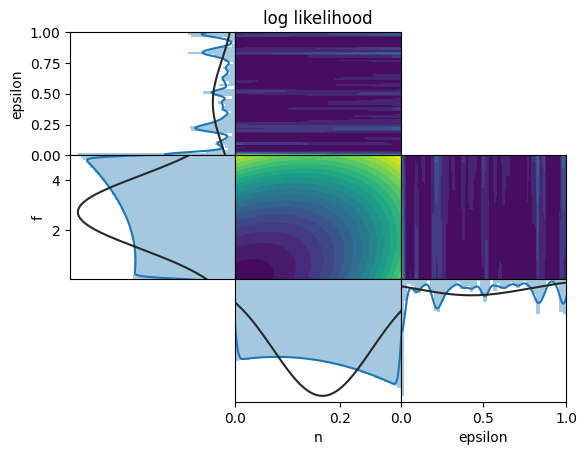

In [169]:


#make also seaborn distribution plots, showing the two variables outside the axes of the loss function
fig, ax = plt.subplots(3, 3)
#ax[0,2].contourf(X, Y, np.log(Z+1), 20)
ax[1,1].contourf(X[:,:,0], Y[:,:,0], np.sum(Z, axis=0), 20)#project epsilon axis, middle
ax[0,1].contourf(X[0,:,:], A[0,:,:], np.sum(Z, axis=1).T[:,::-1], 20)#project f axis, bottom
ax[1,2].contourf(A[:,0,:], Y[:,0,:], np.sum(Z, axis=1).T, 20)#project n axis , right
ax[2,0].axis('off')
ax[0,2].axis('off')
#remove ticks
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[1,2].set_xticks([])
ax[1,2].set_yticks([])
#project Z from n to epsilon
Z_epsilon = []
for i in range(X.shape[0]):
    Z_epsilon.append(round(np.sum(np.sum(Z,axis=1)[i,:])*X.shape[2]/10)*[X[0,i,0]])
#flatten Z_epsilon
Z_epsilon = [item for sublist in Z_epsilon for item in sublist]
sns.distplot(Z_epsilon, ax=ax[0,0], fit=norm, vertical=True)
ax[0,0].invert_xaxis()
#ax[0,0].invert_yaxis()
ax[0,0].set_ylim(epsilon_range)
ax[0,0].set_ylabel("epsilon")
ax[0,0].set_xlabel("")
ax[0,0].set_xticks([])
#project Z from n to f
Z_f = []
for i in range(X.shape[1]):
    Z_f.append(round(np.sum(np.sum(Z,axis=0)[i,:])*X.shape[2]/10)*[Y[i,0,0]])
#flatten Z_f
Z_f = [item for sublist in Z_f for item in sublist]
sns.distplot(Z_f, ax=ax[1,0], fit=norm, vertical=True)
ax[1,0].invert_xaxis()
ax[0,1].invert_yaxis()
ax[1,0].set_ylim(f_range)
ax[1,0].set_ylabel("f")
ax[1,0].set_xlabel("")
ax[1,0].set_xticks([])

#project Z from f to n
Z_n = []
for i in range(X.shape[2]):
    Z_n.append(round(np.sum(np.sum(Z,axis=0)[:,i])*X.shape[0]/10)*[A[0,0,i]])
#flatten Z_n
Z_n = [item for sublist in Z_n for item in sublist]
sns.distplot(Z_n, ax=ax[2,1], fit=norm, vertical=False)
ax[2,1].invert_xaxis()
ax[2,1].invert_yaxis()
ax[2,1].set_xlim(n_range)
ax[2,1].set_xlabel("n")
ax[2,1].set_ylabel("")
ax[2,1].set_yticks([])

#project Z from f to epsilon
Z_f_epsilon = []
for i in range(X.shape[1]):
    Z_f_epsilon.append(round(np.sum(np.sum(Z,axis=1)[i,:])*X.shape[0]/10)*[X[0,i,0]])
#flatten Z_epsilon
Z_f_epsilon = [item for sublist in Z_f_epsilon for item in sublist]
sns.distplot(Z_f_epsilon, ax=ax[2,2], fit=norm)
ax[2,2].invert_yaxis()
ax[2,2].set_xlim(epsilon_range)
ax[2,2].set_xlabel("epsilon")
ax[2,2].set_ylabel("")
ax[2,2].set_yticks([])

ax[0,1].set_title("log likelihood")

#remove spacing between subplots
plt.subplots_adjust(wspace=0, hspace=0)

#save as vector graphic
plt.savefig("log_likelihood.svg")

plt.show()